In [8]:
!pip install pettingzoo[atari] autorom[accept-rom-license] -q
!AutoROM --accept-license

AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms
	/usr/local/lib/python3.12/dist-packages/multi_agent_ale_py/roms

Existing ROMs will be overwritten.


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import time
import cv2
import matplotlib.pyplot as plt
from collections import deque
from pettingzoo.atari import boxing_v2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def preprocess_frame(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    resized = cv2.resize(gray, (84, 84), interpolation=cv2.INTER_AREA)
    return resized.astype(np.float32) / 255.0

class FrameStack:
    def __init__(self):
        self.frames = deque(maxlen=4)
    def reset(self, frame):
        p = preprocess_frame(frame)
        for _ in range(4):
            self.frames.append(p)
        return np.stack(list(self.frames), axis=0)
    def step(self, frame):
        self.frames.append(preprocess_frame(frame))
        return np.stack(list(self.frames), axis=0)

class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)
    def push(self, s, a, r, ns, d):
        self.buffer.append((s, a, r, ns, d))
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, ns, d = zip(*batch)
        return (torch.FloatTensor(np.array(s)),
                torch.LongTensor(a),
                torch.FloatTensor(r),
                torch.FloatTensor(np.array(ns)),
                torch.FloatTensor(d))
    def __len__(self):
        return len(self.buffer)

class DQN(nn.Module):
    def __init__(self, n_actions):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(4, 32, 8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2), nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=1), nn.ReLU()
        )
        self.fc = nn.Sequential(
            nn.Linear(64*7*7, 512), nn.ReLU(),
            nn.Linear(512, n_actions)
        )
    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

class DQNAgent:
    def __init__(self, n_actions, device):
        self.n_actions = n_actions
        self.device = device
        self.online_net = DQN(n_actions).to(device)
        self.target_net = DQN(n_actions).to(device)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()
        self.optimizer = optim.Adam(self.online_net.parameters(), lr=0.0001)
        self.replay_buffer = ReplayBuffer(capacity=10000)
        self.frame_stack = FrameStack()
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_min = 0.1
        self.epsilon_decay = 0.9995
        self.batch_size = 16
        self.target_update = 500
        self.steps = 0

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.n_actions - 1)
        s = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            return self.online_net(s).argmax().item()

    def train_step(self):
        if len(self.replay_buffer) < self.batch_size:
            return None
        s, a, r, ns, d = self.replay_buffer.sample(self.batch_size)
        s  = s.to(self.device)
        a  = a.to(self.device)
        r  = r.to(self.device)
        ns = ns.to(self.device)
        d  = d.to(self.device)
        curr_q = self.online_net(s).gather(1, a.unsqueeze(1))
        with torch.no_grad():
            max_next_q = self.target_net(ns).max(1)[0]
            target_q = r + self.gamma * max_next_q * (1 - d)
        loss = nn.MSELoss()(curr_q.squeeze(), target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        self.steps += 1
        if self.steps % self.target_update == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())
        return loss.item()

# Quick verify
test = DQNAgent(n_actions=18, device=device)
print("epsilon_min:", test.epsilon_min)
print("epsilon_decay:", test.epsilon_decay)
print("✅ All classes ready!")

Device: cuda
epsilon_min: 0.1
epsilon_decay: 0.9995
✅ All classes ready!


In [10]:
agent1 = DQNAgent(n_actions=18, device=device)
agent2 = DQNAgent(n_actions=18, device=device)

episode_rewards1 = []
episode_rewards2 = []
win_history = []

NUM_EPISODES = 200
MAX_STEPS    = 500
PRINT_EVERY  = 10

print("🥊 Starting Training...")
print(f"Episodes: {NUM_EPISODES} | Max steps: {MAX_STEPS} | Device: {device}")
print("="*50)

start_time = time.time()

for episode in range(1, NUM_EPISODES + 1):
    env = boxing_v2.env()
    env.reset()

    state1 = agent1.frame_stack.reset(env.observe("first_0"))
    state2 = agent2.frame_stack.reset(env.observe("second_0"))

    total_reward1 = 0
    total_reward2 = 0
    step = 0

    for agent_name in env.agent_iter():
        obs, reward, terminated, truncated, _ = env.last()
        done = terminated or truncated

        if done:
            env.step(None)
            break

        if agent_name == "first_0":
            action = agent1.select_action(state1)
            next_state = agent1.frame_stack.step(obs)
            agent1.replay_buffer.push(state1, action, reward, next_state, float(done))
            state1 = next_state
            total_reward1 += reward
            agent1.train_step()
        else:
            action = agent2.select_action(state2)
            next_state = agent2.frame_stack.step(obs)
            agent2.replay_buffer.push(state2, action, reward, next_state, float(done))
            state2 = next_state
            total_reward2 += reward
            agent2.train_step()

        env.step(action)
        step += 1
        if step >= MAX_STEPS:
            break

    env.close()

    episode_rewards1.append(total_reward1)
    episode_rewards2.append(total_reward2)

    if total_reward1 > total_reward2:
        win_history.append(1)
    elif total_reward2 > total_reward1:
        win_history.append(2)
    else:
        win_history.append(0)

    if episode % PRINT_EVERY == 0:
        elapsed = time.time() - start_time
        print(f"Episode {episode}/{NUM_EPISODES} | "
              f"R1: {total_reward1:.1f} R2: {total_reward2:.1f} | "
              f"Wins → A1: {win_history.count(1)} A2: {win_history.count(2)} | "
              f"ε: {agent1.epsilon:.3f} | Time: {elapsed:.0f}s")

print("="*50)
print(f"✅ Training Complete!")
print(f"Agent 1 wins: {win_history.count(1)}")
print(f"Agent 2 wins: {win_history.count(2)}")
print(f"Draws:        {win_history.count(0)}")

🥊 Starting Training...
Episodes: 200 | Max steps: 500 | Device: cuda
Episode 10/200 | R1: 0.0 R2: 0.0 | Wins → A1: 0 A2: 0 | ε: 0.289 | Time: 34s
Episode 20/200 | R1: 0.0 R2: 0.0 | Wins → A1: 0 A2: 1 | ε: 0.100 | Time: 70s
Episode 30/200 | R1: -3.0 R2: 3.0 | Wins → A1: 1 A2: 4 | ε: 0.100 | Time: 106s
Episode 40/200 | R1: 0.0 R2: 0.0 | Wins → A1: 3 A2: 7 | ε: 0.100 | Time: 141s
Episode 50/200 | R1: 2.0 R2: -2.0 | Wins → A1: 6 A2: 8 | ε: 0.100 | Time: 177s
Episode 60/200 | R1: 0.0 R2: 0.0 | Wins → A1: 7 A2: 9 | ε: 0.100 | Time: 212s
Episode 70/200 | R1: 0.0 R2: 0.0 | Wins → A1: 7 A2: 12 | ε: 0.100 | Time: 247s
Episode 80/200 | R1: 0.0 R2: 0.0 | Wins → A1: 7 A2: 13 | ε: 0.100 | Time: 281s
Episode 90/200 | R1: 0.0 R2: 0.0 | Wins → A1: 7 A2: 14 | ε: 0.100 | Time: 316s
Episode 100/200 | R1: 0.0 R2: 0.0 | Wins → A1: 7 A2: 17 | ε: 0.100 | Time: 351s
Episode 110/200 | R1: -2.0 R2: 2.0 | Wins → A1: 7 A2: 20 | ε: 0.100 | Time: 387s
Episode 120/200 | R1: 0.0 R2: 0.0 | Wins → A1: 9 A2: 20 | ε: 0.10

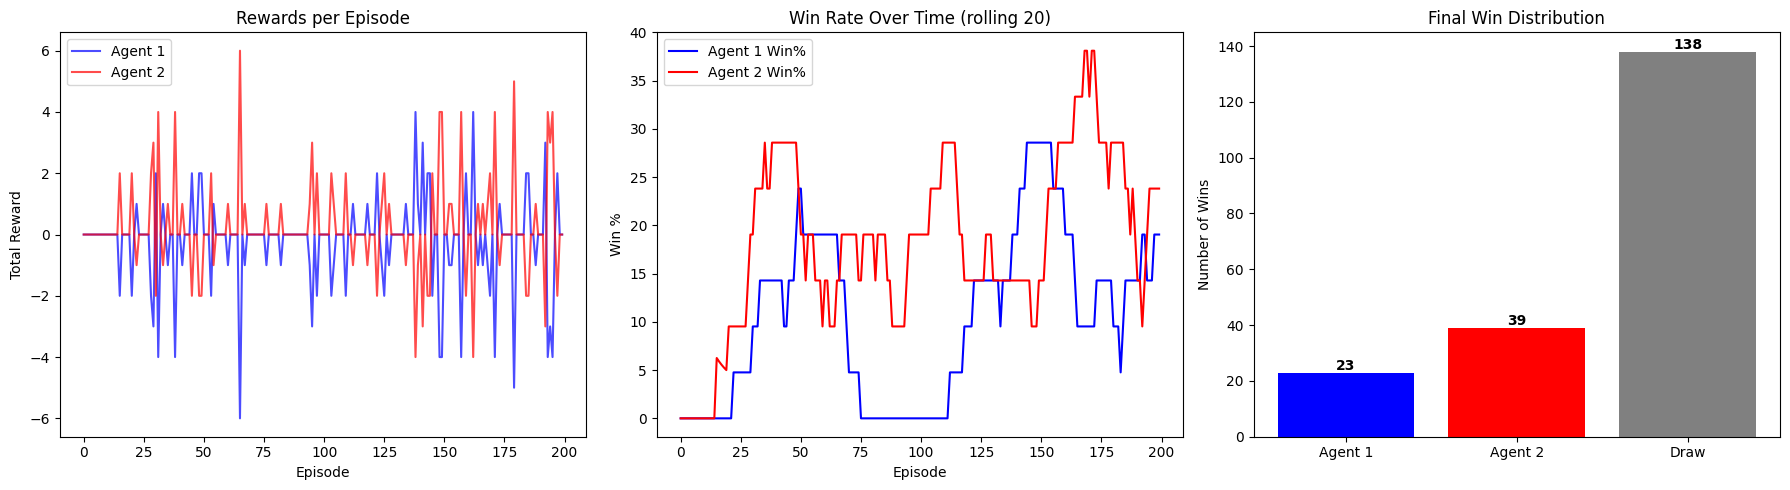

✅ Plots saved!


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Reward curves
axes[0].plot(episode_rewards1, label="Agent 1", alpha=0.7, color="blue")
axes[0].plot(episode_rewards2, label="Agent 2", alpha=0.7, color="red")
axes[0].set_title("Rewards per Episode")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Total Reward")
axes[0].legend()

# Rolling win rate
wins1_rolling = []
wins2_rolling = []
window = 20
for i in range(len(win_history)):
    chunk = win_history[max(0, i-window):i+1]
    wins1_rolling.append(chunk.count(1) / len(chunk) * 100)
    wins2_rolling.append(chunk.count(2) / len(chunk) * 100)

axes[1].plot(wins1_rolling, label="Agent 1 Win%", color="blue")
axes[1].plot(wins2_rolling, label="Agent 2 Win%", color="red")
axes[1].set_title("Win Rate Over Time (rolling 20)")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Win %")
axes[1].legend()

# Final win distribution
labels = ["Agent 1", "Agent 2", "Draw"]
values = [win_history.count(1), win_history.count(2), win_history.count(0)]
colors = ["blue", "red", "gray"]
axes[2].bar(labels, values, color=colors)
axes[2].set_title("Final Win Distribution")
axes[2].set_ylabel("Number of Wins")
for i, v in enumerate(values):
    axes[2].text(i, v + 1, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("training_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plots saved!")

In [12]:
torch.save(agent1.online_net.state_dict(), "agent1_dqn.pth")
torch.save(agent2.online_net.state_dict(), "agent2_dqn.pth")

total = len(win_history)
a1_wins = win_history.count(1)
a2_wins = win_history.count(2)
draws   = win_history.count(0)

print("="*40)
print("       FINAL RESULTS SUMMARY")
print("="*40)
print(f"Total Episodes : {total}")
print(f"Agent 1 Wins   : {a1_wins} ({a1_wins/total*100:.1f}%)")
print(f"Agent 2 Wins   : {a2_wins} ({a2_wins/total*100:.1f}%)")
print(f"Draws          : {draws}  ({draws/total*100:.1f}%)")
print("="*40)
print("✅ Models saved!")

       FINAL RESULTS SUMMARY
Total Episodes : 200
Agent 1 Wins   : 23 (11.5%)
Agent 2 Wins   : 39 (19.5%)
Draws          : 138  (69.0%)
✅ Models saved!
